# Análisis Exploratorio de Datos (EDA)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

# Cargar el Dataset
df = pd.read_csv('data/retailmax.csv')

# 1. ¿Cuál es la distribución de edades de los clientes?

In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


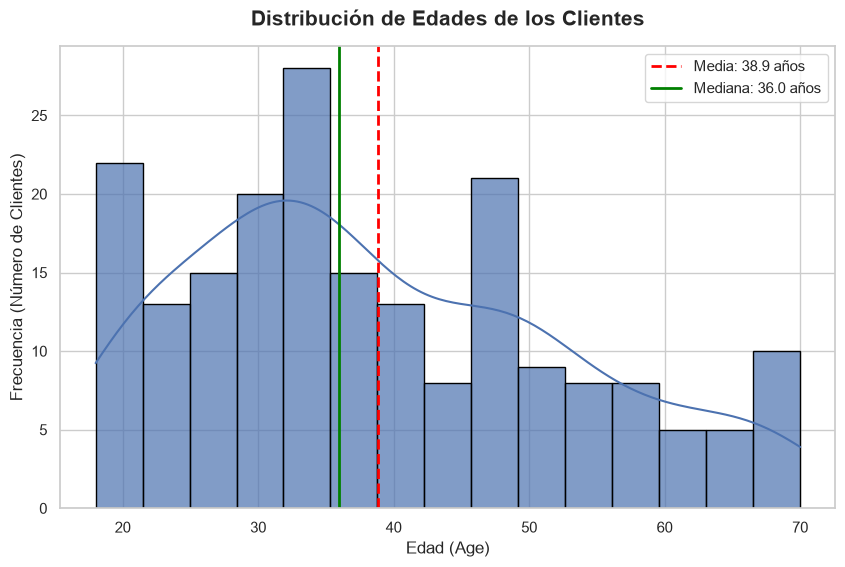

In [5]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10, 6))
sns.histplot(df[['Age']], bins=15, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades de los Clientes', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Frecuencia (Número de Clientes)', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["Age"].mean():.1f} años')
plt.axvline(df['Age'].median(), color='green', linestyle='-', linewidth=2, label=f'Mediana: {df["Age"].median():.1f} años')
plt.legend(fontsize=11)
plt.show()

# 2. ¿Existen diferencias en los ingresos anuales entre hombres y mujeres?

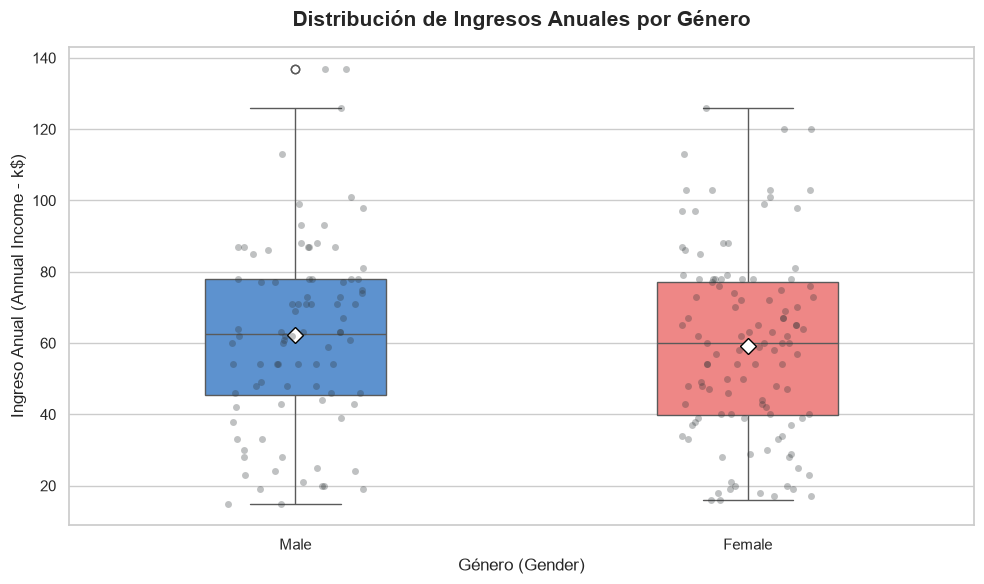

In [6]:
plt.figure(figsize=(10, 6))

# Gráfico de caja (boxplot) con strip plot superpuesto para ver la distribución individual
sns.boxplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    palette={'Male': '#4a90e2', 'Female': '#ff7675'},
    width=0.4,
    showmeans=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Mostrar los puntos individuales de datos de manera sutil
sns.stripplot(
    data=df, 
    x='Gender', 
    y='Annual Income (k$)', 
    color='#2d3436', 
    alpha=0.3, 
    jitter=0.15, 
    size=5
)

plt.title('Distribución de Ingresos Anuales por Género', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Género (Gender)', fontsize=12)
plt.ylabel('Ingreso Anual (Annual Income - k$)', fontsize=12)

plt.tight_layout()
plt.show()

### **Análisis de los Resultados**

Al analizar la distribución de ingresos anuales entre hombres y mujeres, observamos que **no existen diferencias drásticas**, aunque sí se aprecian ligeras variaciones a favor del grupo masculino:

1. **Promedio (Media) y Mediana:**
   - Los **hombres** tienen un ingreso anual promedio de **62.23 k$** y una mediana de **62.50 k$**.
   - Las **mujeres** tienen un ingreso anual promedio de **59.25 k$** y una mediana de **60.00 k$**.
   - Esto representa una ligera diferencia de **~2.98 k$ en la media** y **2.50 k$ en la mediana** a favor de los hombres.

2. **Dispersión y Límites:**
   - La dispersión (desviación estándar) es sumamente similar en ambos grupos: **26.64 k$** para hombres y **26.01 k$** para mujeres.
   - Los rangos intercuartílicos y las cajas en el gráfico muestran que el 50% central de la población se encuentra en rangos muy similares, aunque el límite inferior del 25% de los hombres (45.5 k$) es ligeramente mayor al de las mujeres (39.75 k$).
   - El ingreso máximo registrado pertenece a un hombre con **137 k$**, mientras que el de las mujeres es de **126 k$**.

**Conclusión:** Aunque estadísticamente los hombres muestran ingresos ligeramente superiores en términos de medidas de tendencia central (media y mediana) y valores máximos, las distribuciones se superponen en gran medida. Esto sugiere que **el género no es un factor determinante o altamente diferenciador** para el nivel de ingresos en este conjunto de datos.

# 3. ¿Cómo se distribuye la puntuación de gastos entre los diferentes rangos de edades?

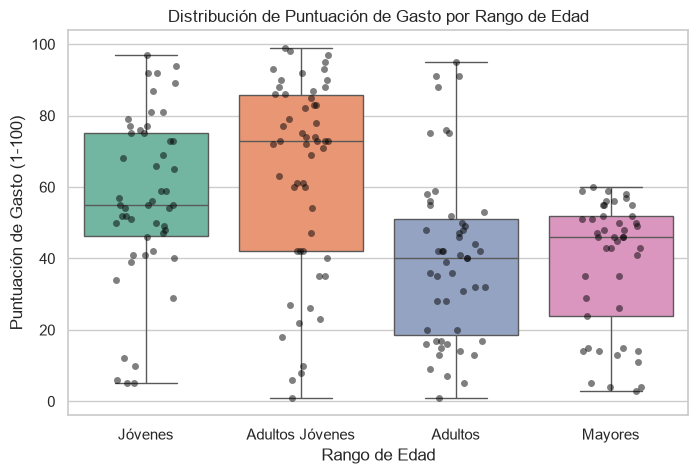

In [25]:
# Crear rangos de edad para una mejor visualización en gráfico de cajas
# Divide la edad en 4 grupos con la misma cantidad de clientes
df['Age Group'] = pd.qcut(df['Age'], q=4, labels=['Jóvenes', 'Adultos Jóvenes', 'Adultos', 'Mayores'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Age Group', y='Spending Score (1-100)', palette='Set2')
sns.stripplot(data=df, x='Age Group', y='Spending Score (1-100)', color='black', alpha=0.5, jitter=0.2)
plt.title('Distribución de Puntuación de Gasto por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.show()


## Análisis: Distribución de Puntuación de Gasto por Rango de Edad

* Los "Adultos Jóvenes" lideran el gasto real: Al corregir el sesgo, la caja naranja (Adultos Jóvenes) se desplaza notablemente hacia arriba. Su mediana se sitúa por encima de los 70 puntos, superando claramente a los Jóvenes (verde), cuya mediana está cerca de los 55.
* El grupo "Adultos" es el que menos gasta: La caja azul (Adultos) cae al fondo de la gráfica, con una mediana de 40 puntos y la mayor parte de su densidad concentrada en la mitad inferior de la escala de gasto.
* Los "Mayores" son consistentes y moderados: La caja rosa (Mayores) se estabiliza. Su mediana se sitúa muy cerca de los 45-50 puntos y sus límites son compactos, confirmando que es un grupo con hábitos de consumo predecibles y de bajo riesgo.

# 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?

El coeficiente de correlación de Pearson es: 0.0099


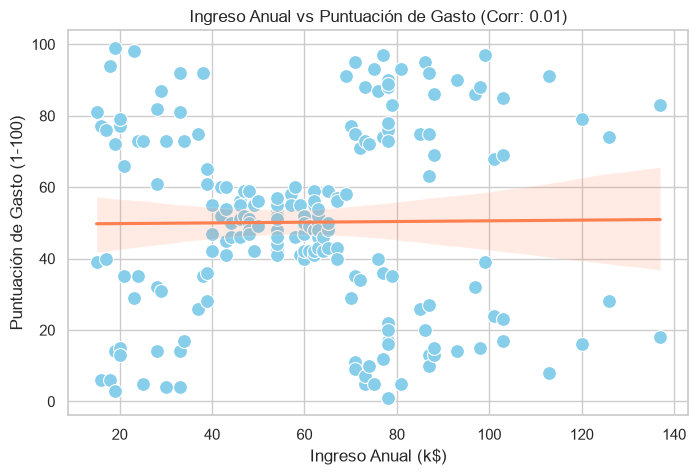

In [13]:
correlacion = df['Annual Income (k$)'].corr(df['Spending Score (1-100)'])
print(f"El coeficiente de correlación de Pearson es: {correlacion:.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', s=100, color='skyblue')
sns.regplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', scatter=False, color='coral')
plt.title(f'Ingreso Anual vs Puntuación de Gasto (Corr: {correlacion:.2f})')
plt.xlabel('Ingreso Anual (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.show()

## Análisis: Ingreso Anual vs. Puntuación de Gasto

* No existe correlación lineal: El coeficiente de correlación es prácticamente cero (0.01), y la línea de tendencia es totalmente plana. El dinero que ganan no determina directamente cuánto gastan mediante un análisis lineal simple.
* Se observan 5 grupos muy claros (clusters): Aunque no hay una relación lineal, los datos forman un patrón visual evidente:
   * Ingreso bajo - Gasto alto (arriba a la izquierda).
   * Ingreso bajo - Gasto bajo (abajo a la izquierda).
   * Ingreso medio - Gasto medio (al centro, muy concentrado entre 40 y 60k).
   * Ingreso alto - Gasto alto (arriba a la derecha).
   * Ingreso alto - Gasto bajo (abajo a la derecha).
* El centro es la zona más predecible: Los clientes con ingresos entre 40k y 70k tienen un comportamiento sumamente homogéneo, manteniendo todos una puntuación de gasto media-moderada.

# 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?

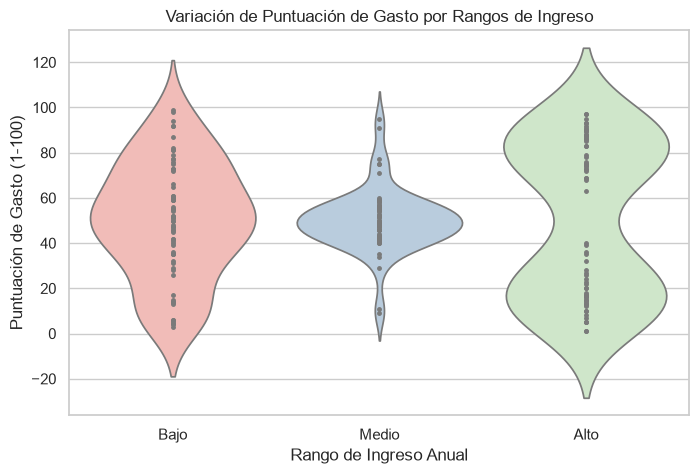

In [24]:
# Crear rangos de ingresos aproximados para los datos provistos
df['Income Group'] = pd.qcut(df['Annual Income (k$)'],  q=3, labels=['Bajo', 'Medio', 'Alto'])

plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='Income Group', y='Spending Score (1-100)', palette='Pastel1', inner='point')
plt.title('Variación de Puntuación de Gasto por Rangos de Ingreso')
plt.xlabel('Rango de Ingreso Anual')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.show()

## Análisis: Variación de Puntuación de Gasto por Rangos de Ingreso

Al dividir los ingresos en tres partes equitativas usando cuantiles, encontramos que:

* Ingreso Medio = Gasto Medio Predice el comportamiento: El violín Medio (azul) se ensancha drásticamente en el centro (alrededor de los 50 puntos). Los clientes con ingresos intermedios tienen un comportamiento sumamente homogéneo y controlado; casi ninguno gasta de más ni de menos.
* Ingreso Alto = Comportamiento Polarizado: El violín Alto (verde) toma una forma clara de "reloj de arena". Muestra dos grandes bultos en los extremos: un grupo que gana mucho y gasta muchísimo (arriba), y otro grupo que gana mucho pero es sumamente ahorrador (abajo). Casi nadie en este rango tiene un gasto promedio.
* Ingreso Bajo = Distribución Uniforme con sesgo moderado: El violín Bajo (rosa) es el más ancho y distribuido de forma vertical. Esto indica que los clientes de menores ingresos se esparcen por todos los niveles de gasto, teniendo una ligera concentración en la zona media-alta (alrededor de los 55 puntos).

# 6. ¿Cuál es la proporción de clientes por género?

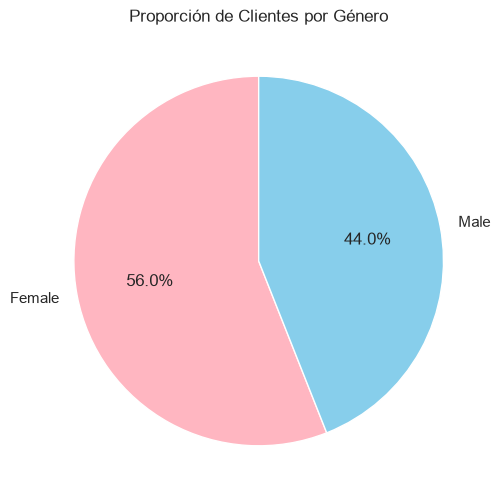

In [15]:
plt.figure(figsize=(6, 6))
# Contar frecuencias de género
gender_counts = df['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightpink', 'skyblue'], startangle=90)
plt.title('Proporción de Clientes por Género')
plt.show()


## Análisis: Proporción de Clientes por Género

* Mayoría femenina en la base de clientes: Las mujeres (Female) representan el 56.0% del total de la muestra, superando a los hombres por un margen claro.
* Presencia masculina significativa: Los hombres (Male) constituyen el 44.0% restante de los usuarios registrados en este conjunto de datos.
* Muestra relativamente balanceada: Aunque existe una inclinación hacia el público femenino, la diferencia es de solo 12 puntos porcentuales, lo que permite realizar comparaciones estadísticas confiables entre ambos grupos.

# 7. ¿Qué grupos de edad gastan más en promedio?

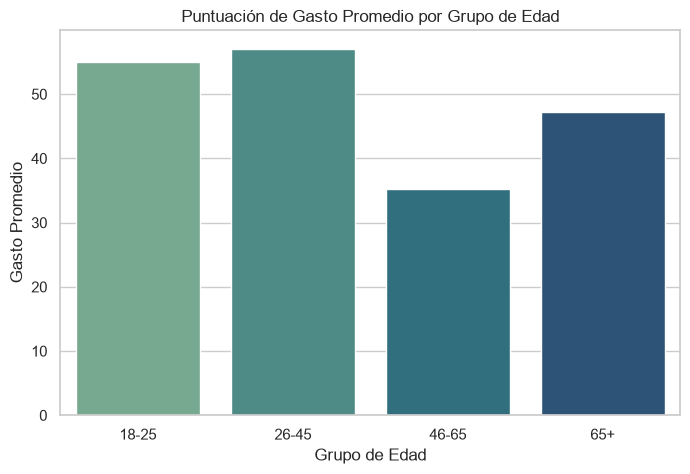

In [17]:
# Asegurar la columna de grupos creada en el punto 1
if 'Age Group' not in df.columns:
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 25, 45, 65, 100], labels=['18-25', '26-45', '46-65', '65+'])

# Agrupar y calcular promedio
df_age_spending = df.groupby('Age Group', observed=False)['Spending Score (1-100)'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_age_spending, x='Age Group', y='Spending Score (1-100)', palette='crest')
plt.title('Puntuación de Gasto Promedio por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Gasto Promedio')
plt.show()


## Análisis: Puntuación de Gasto Promedio por Grupo de Edad

* Los adultos jóvenes gastan más en promedio: El grupo de 26-45 años registra el promedio de gasto más alto de toda la muestra, superando ligeramente los 55 puntos.
* Consumo sólido en jóvenes: El rango de 18-25 años ocupa el segundo lugar con un promedio muy cercano, manteniéndose por encima de los 50 puntos.
* El grupo de 46-65 es el que menos gasta: Muestra una caída drástica en su promedio, situándose como el segmento con menor consumo (alrededor de 35 puntos).
* Repunte en los adultos mayores: Sorprendentemente, el grupo de 65+ gasta más en promedio (cerca de 47 puntos) que el segmento que le precede (46-65), consolidándose como un público con gasto moderado-alto estable.

# 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?

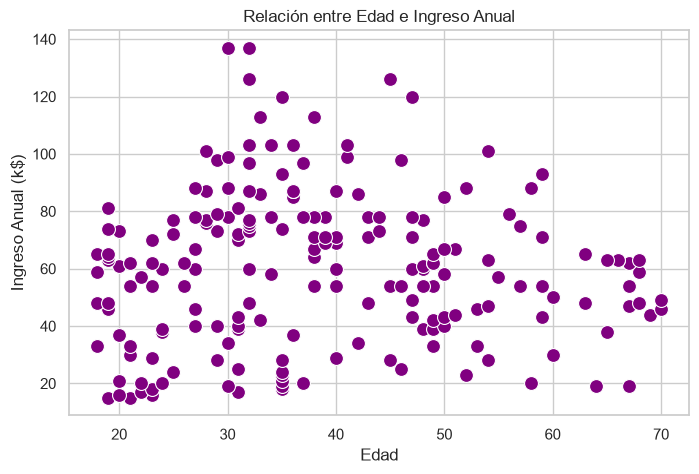

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Annual Income (k$)', s=100, color='purple')
plt.title('Relación entre Edad e Ingreso Anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual (k$)')
plt.show()


## Análisis: Relación entre Edad e Ingreso Anual

* Sin tendencia lineal clara: Los puntos están dispersos por todo el gráfico, lo que indica que la edad no determina directamente los ingresos de los clientes.
* El pico de ingresos ocurre entre los 30 y 45 años: Los ingresos más altos de la muestra (por encima de 120k$) se concentran estrictamente en personas adultas de este rango de edad.
* Jóvenes y adultos mayores ganan menos: Los menores de 25 años y los mayores de 65 años no superan la barrera de los 85k$ anuales, manteniéndose en niveles de ingresos bajos a moderados.
* Alta densidad en ingresos medios: Existe una fuerte acumulación de clientes de todas las edades (de 20 a 70 años) que ganan entre 40k$y 80k$.

# 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?

<Figure size 800x500 with 0 Axes>

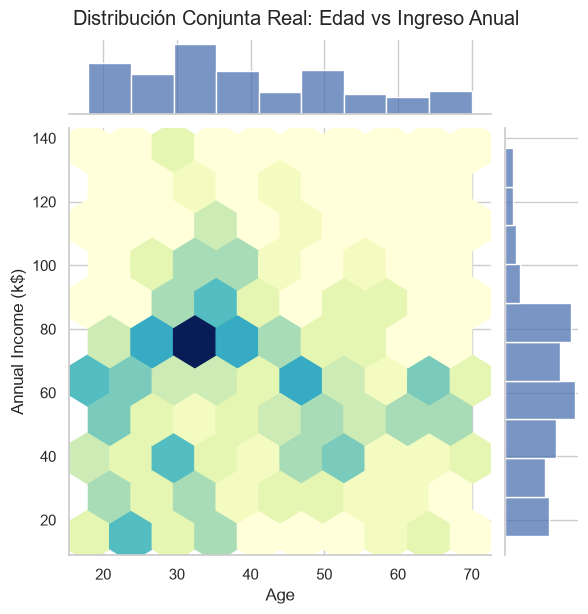

In [26]:
# Al ser una muestra pequeña, se usa un scatter plot con un mapa de densidad (kde) superpuesto o marginales
plt.figure(figsize=(8, 5))
sns.jointplot(data=df, x='Age', y='Annual Income (k$)', kind='hex', cmap='YlGnBu')
plt.gcf().suptitle('Distribución Conjunta Real: Edad vs Ingreso Anual', y=1.02)
plt.show()



## Reanálisis: Distribución Conjunta Real: Edad vs. Ingreso Anual 

* El "Núcleo" del negocio (Epicentro): El hexágono azul marino/negro destaca de forma masiva. Nos dice que la mayor concentración absoluta de clientes se compone de personas de aproximadamente 32 años con ingresos de 75k$a 80k$ anuales.
* Dispersión en edades avanzadas: A partir de los 50 años, los hexágonos se vuelven de color amarillo claro y verde muy tenue, además de dispersarse. Esto confirma que el segmento de clientes mayores es muy pequeño, esporádico y no tiene un patrón de ingresos definido.
* Segmento joven de bajos ingresos: En la esquina inferior izquierda (cerca de los 23 años y 20k$) se nota otro pequeño punto de acumulación (verde turquesa), lo que delata un subgrupo de clientes jóvenes que apenas inician su vida laboral.

# 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?

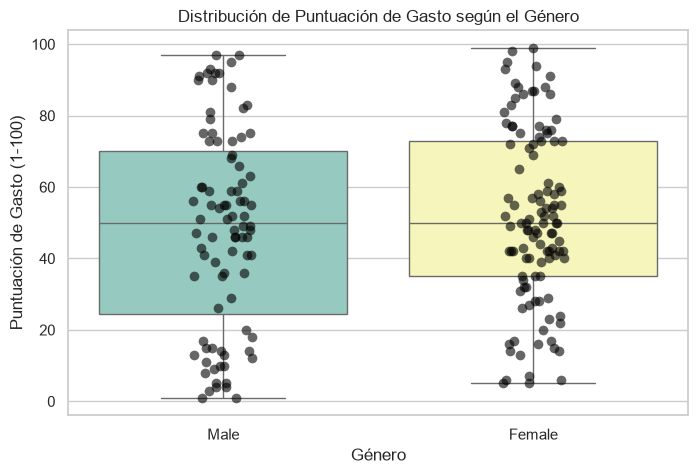

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Gender', y='Spending Score (1-100)', palette='Set3')
# Añadir los puntos para ver el comportamiento individual debido a la muestra pequeña
sns.stripplot(data=df, x='Gender', y='Spending Score (1-100)', color='black', alpha=0.6, size=7)
plt.title('Distribución de Puntuación de Gasto según el Género')
plt.xlabel('Género')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.show()


## Análisis: Distribución de Puntuación de Gasto según el Género

* Mediana idéntica: El nivel de gasto central o mediana es exactamente el mismo para hombres (Male) y mujeres (Female), situándose justo en los 50 puntos.
* Comportamiento sumamente similar: La dispersión de los puntos individuales (stripplot) muestra que ambos géneros cubren casi todo el espectro, desde puntuaciones cercanas a 0 hasta el máximo de 100.
* Ligera diferencia en los cuartiles: El grupo de las mujeres tiene una caja un poco más compacta y ligeramente desplazada hacia arriba en su rango intercuartílico (percentil 25 al 75), lo que sugiere que su gasto mínimo frecuente es un poco más alto que el de los hombres, aunque la diferencia es mínima.
* Conclusión: El género no es una variable determinante por sí sola para segmentar a los clientes según su nivel de gasto, ya que ambos grupos se comportan de manera casi idéntica.